<a href="https://colab.research.google.com/github/nahushdeshmukh17/forage-midas/blob/flow/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Project Members:
1. Nahush Deshmukh   - PRN: 202502110006
2. Snehal Pagare     - PRN: 202502110003
3. Chirag Nagawde    - PRN: 202502110009
4. Gayatri Gaikwad   - PRN: 202502110002






Project Summary:
In this project, we worked on a dataset of Parkinson’s disease handwriting samples (spiral and wave drawings)
to identify early signs of Parkinson’s using image-based feature engineering. We used Google Colab with GPU support
and mounted Google Drive to store and access our dataset easily. The data was obtained from Kaggle using the API key.
We explored the dataset and confirmed that it contained two classes — “healthy” and “parkinson”. Then we preprocessed
the images by converting them to grayscale, resizing them to 128x128 pixels, and normalizing pixel values between 0 and 1.
We encoded the labels into numeric form for model training.

For feature extraction, we used a pretrained VGG16 model (without its top classification layers) to extract deep image
features instead of relying on raw pixel data. These features were flattened into a 2D array to be used by traditional
machine learning models. After that, we split the data into training and testing sets and standardized the feature values
using StandardScaler. We trained a Logistic Regression model to classify the images, achieving around 90% accuracy —
showing that the extracted features were highly effective.

Next, we applied feature engineering techniques like PCA (Principal Component Analysis) to reduce the dimensionality
of the feature set while preserving about 89% of the data variance, and also used VarianceThreshold to remove
low-variance features. Even after these optimizations, our model maintained similar accuracy, proving that
we successfully reduced complexity without sacrificing performance.

Overall, this project demonstrates how proper preprocessing, deep feature extraction, and feature engineering
can improve model efficiency and performance in medical image analysis tasks.
"""


!pip install --upgrade pip
!pip install pandas numpy scikit-learn tensorflow pillow opencv-python matplotlib seaborn kaggle tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)


TensorFlow version: 2.19.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)


TensorFlow version: 2.19.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!mkdir -p /content/drive/MyDrive/Feature_Engineering_Project/data
!mkdir -p /content/drive/MyDrive/Feature_Engineering_Project/notebooks
!ls -la /content/drive/MyDrive/Feature_Engineering_Project || true


In [ ]:
import os
print("Folders:", os.listdir("/content/drive/MyDrive/Feature_Engineering_Project"))


In [ ]:
from google.colab import files

# asking the user (me) to upload the kaggle.json file manually
# this file contains my Kaggle API credentials — it's needed to download datasets directly from Kaggle
print("Upload kaggle.json now (downloaded from your Kaggle settings).")

# opening a file upload prompt in Colab so I can pick and upload kaggle.json
uploaded = files.upload()


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!DATA_PATH="/content/drive/MyDrive/Feature_Engineering_Project/data"
!echo $DATA_PATH


In [ ]:
# set path (adjust if you used a different Drive folder)
DATA_PATH="/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson"
!mkdir -p "$DATA_PATH"
# download Kaggle dataset (Parkinson's Drawings)
!kaggle datasets download -d kmader/parkinsons-drawings -p "$DATA_PATH"
# unzip all into the same folder
!unzip -q "$DATA_PATH/parkinsons-drawings.zip" -d "$DATA_PATH"
!ls -la "$DATA_PATH"

In [ ]:
import os, glob
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# defining the main directory where my dataset is stored
DATA_PATH = "/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson"

# searching for all .png and .jpg files in all subfolders of the dataset
# glob + recursive=True helps automatically go through all nested folders
img_files = glob.glob(os.path.join(DATA_PATH, "**", "*.png"), recursive=True) + \
            glob.glob(os.path.join(DATA_PATH, "**", "*.jpg"), recursive=True)

# displaying how many image files were found in total
print("Total images found:", len(img_files))

# showing a few random images just to visually confirm the dataset looks correct
fig, axs = plt.subplots(1, 4, figsize=(12, 4))
for i, p in enumerate(img_files[:4]):  # loop through first 4 images
    im = Image.open(p).convert("L")   # open image and convert to grayscale
    axs[i].imshow(im, cmap="gray")    # display the image in grayscale mode
    axs[i].axis("off")                # hide the axis ticks and labels for clarity
    axs[i].set_title(os.path.basename(os.path.dirname(p)))  # show folder name as label (usually class)
plt.show()                            # finally render the images


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import numpy as np

DATA_PATH = "/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson"

# count images by label
labels = []
for subdir, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            label = os.path.basename(subdir)
            labels.append(label)

label_counts = Counter(labels)
df_counts = pd.DataFrame.from_dict(label_counts, orient='index', columns=['count'])
display(df_counts)

# visualize class distribution
plt.figure(figsize=(6,4))
plt.bar(df_counts.index, df_counts['count'], color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.show()

# check image dimensions and color modes
sizes = []
for subdir, dirs, files in os.walk(DATA_PATH):
    for file in files[:50]:  # sample 50 images
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(subdir, file)
            img = Image.open(path)
            sizes.append(img.size)

sizes_arr = np.array(sizes)
print("Average image size (width x height):", sizes_arr.mean(axis=0))


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

# setting the size to which all images will be resized — smaller images make training faster
IMG_SIZE = (128, 128)

# initializing empty lists to store all image arrays and their corresponding labels
X, y = [], []

# looping through every folder and file in the dataset directory
for subdir, dirs, files in os.walk(DATA_PATH):
    for file in tqdm(files):  # tqdm just gives a nice progress bar
        # checking only image files with these extensions
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            # extracting the folder name as the label (either healthy or parkinson)
            label = os.path.basename(subdir)
            # creating the full path to the image file
            path = os.path.join(subdir, file)
            # loading the image in grayscale mode and resizing it to 128x128
            img = load_img(path, color_mode='grayscale', target_size=IMG_SIZE)
            # converting the image into a numerical array and normalizing pixel values between 0–1
            img_array = img_to_array(img) / 255.0
            # storing the processed image and its label
            X.append(img_array)
            y.append(label)

# converting lists into numpy arrays so they can be used in ML models
X = np.array(X)
y = np.array(y)

# printing shapes to confirm the data loaded correctly
print("Image array shape:", X.shape)
print("Labels shape:", y.shape)

# encoding text labels ('healthy', 'parkinson') into numeric form (0 and 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# printing label mapping and a few encoded samples for verification
print("Label classes:", le.classes_)
print("Encoded labels (sample):", y_encoded[:10])


In [ ]:
!ls -la "/content/drive/MyDrive/Feature_Engineering_Project"


In [ ]:

import os
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

DATA_PATH = "/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson"
IMG_SIZE = (128, 128)

X, y = [], []

print("Loading and preprocessing images...")

for subdir, dirs, files in os.walk(DATA_PATH):
    for file in tqdm(files):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            label = os.path.basename(subdir)
            path = os.path.join(subdir, file)
            img = load_img(path, color_mode='grayscale', target_size=IMG_SIZE)
            img_array = img_to_array(img) / 255.0  # normalize 0–1
            X.append(img_array)
            y.append(label)

X = np.array(X)
y = np.array(y)

# Encode labels: healthy=0, parkinson=1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("✅ Done loading images")
print("Image array shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", le.classes_)



Loading and preprocessing images...
✅ Done loading images
Image array shape: (0,)
Labels shape: (0,)
Classes: []


In [ ]:
!ls -R "/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson"


ls: cannot access '/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson': No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive


'Colab Notebooks'
'Document from Nahush Deshmukh'
 Feature_Engineering_Project
'nahush final case study.pdf'
 ndimg1.png
 ndimg2.png
'Problem_Solving_Problem_Statements OPPS with Java.xlsx'
 Screenshot_2025-09-20-21-03-12-663_com.phonepe.app.jpg


In [ ]:
!ls -R "/content/drive/MyDrive/Feature_Engineering_Project"


/content/drive/MyDrive/Feature_Engineering_Project:
data  data_parkinson  notebooks

/content/drive/MyDrive/Feature_Engineering_Project/data:

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson:
drawings  parkinsons-drawings.zip  spiral  wave

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings:
spiral	wave

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral:
testing  training

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing:
healthy  parkinson

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy:
V01HE01.png  V04HE01.png  V07HE01.png  V10HE01.png  V55HE13.png
V02HE01.png  V05HE01.png  V08HE01.png  V11HE01.png  V55HE14.png
V03HE1.png   V06HE01.png  V09HE01.png  V55HE12.png  V55HE15.png

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/parkinson:
V01PE01.png  V03PE04.png  V05PE01.png  V08PE01

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson"


In [ ]:
!ls "$DATA_PATH"


drawings  parkinsons-drawings.zip  spiral  wave


In [ ]:
!ls -R "/content/drive/MyDrive/Feature_Engineering_Project

/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [ ]:
import os, glob
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

DATA_PATH = "/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson"
IMG_SIZE = (128, 128)

X, y = [], []

print("Loading and preprocessing images...")

for folder in ["drawings", "spiral", "wave"]:
    folder_path = os.path.join(DATA_PATH, folder)
    for filepath in tqdm(glob.glob(folder_path + "/**/*.png", recursive=True)):
        label = "healthy" if "healthy" in filepath.lower() else "parkinson"
        img = load_img(filepath, color_mode='grayscale', target_size=IMG_SIZE)
        img_array = img_to_array(img) / 255.0
        X.append(img_array)
        y.append(label)

X = np.array(X)
y = np.array(y)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("✅ Done loading")
print("Total images:", len(X))
print("Image shape:", X.shape)
print("Classes:", le.classes_)


Loading and preprocessing images...


0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]

✅ Done loading
Total images: 0
Image shape: (0,)
Classes: []


In [ ]:
!find "/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson" -type f | head -20


find: ‘/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson’: No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive



'Colab Notebooks'
'Document from Nahush Deshmukh'
 Feature_Engineering_Project
'nahush final case study.pdf'
 ndimg1.png
 ndimg2.png
'Problem_Solving_Problem_Statements OPPS with Java.xlsx'
 Screenshot_2025-09-20-21-03-12-663_com.phonepe.app.jpg


In [ ]:
!ls -R "/content/drive/MyDrive/Feature_Engineering_Project"


/content/drive/MyDrive/Feature_Engineering_Project:
data  data_parkinson  notebooks

/content/drive/MyDrive/Feature_Engineering_Project/data:

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson:
drawings  parkinsons-drawings.zip  spiral  wave

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings:
spiral	wave

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral:
testing  training

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing:
healthy  parkinson

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy:
V01HE01.png  V04HE01.png  V07HE01.png  V10HE01.png  V55HE13.png
V02HE01.png  V05HE01.png  V08HE01.png  V11HE01.png  V55HE14.png
V03HE1.png   V06HE01.png  V09HE01.png  V55HE12.png  V55HE15.png

/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/parkinson:
V01PE01.png  V03PE04.png  V05PE01.png  V08PE01

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Feature_Engineering_Project"
!ls "$DATA_PATH"


data  data_parkinson  notebooks


In [ ]:
!find /content/drive/MyDrive/Feature_Engineering_Project -type f \( -iname "*.png" -o -iname "*.jpg" -o -iname "*.jpeg" \) | head -25



/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy/V01HE01.png
/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy/V09HE01.png
/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy/V02HE01.png
/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy/V55HE12.png
/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy/V08HE01.png
/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy/V55HE15.png
/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy/V04HE01.png
/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy/V55HE13.png
/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings/spiral/testing/healthy/V55HE14.png
/content/d

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Feature_Engineering_Project/data_parkinson/drawings"
!ls "$DATA_PATH"


spiral	wave


In [ ]:
import os, glob
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

# defining a fixed image size so that all images have the same shape
IMG_SIZE = (128, 128)
X, y = [], []  # lists to store image arrays and their corresponding labels

print("Loading and preprocessing images...")

# recursively scan through all files in the dataset folder
# tqdm just shows a progress bar so I can track the loading progress
for filepath in tqdm(glob.glob(DATA_PATH + "/**/*.*", recursive=True)):
    # filtering only valid image formats
    if filepath.lower().endswith(('.png', '.jpg', '.jpeg')):
        # checking the path name to assign the correct label
        label = "healthy" if "healthy" in filepath.lower() else "parkinson"

        # loading image in grayscale mode and resizing it to 128x128
        img = load_img(filepath, color_mode='grayscale', target_size=IMG_SIZE)

        # converting the image to an array and normalizing pixel values between 0–1
        img_array = img_to_array(img) / 255.0

        # storing the image and its label
        X.append(img_array)
        y.append(label)

# converting the lists into numpy arrays for model processing
X = np.array(X)
y = np.array(y)

# encoding text labels (healthy/parkinson) into numeric form (0/1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("✅ Done loading")
print("Total images:", len(X))
print("Image shape:", X.shape)
print("Classes:", le.classes_)


Loading and preprocessing images...


100%|██████████| 204/204 [01:21<00:00,  2.50it/s]

✅ Done loading
Total images: 204
Image shape: (204, 128, 128, 1)
Classes: ['healthy' 'parkinson']


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

# VGG16 model is trained on RGB images (3 channels),
# but my dataset is grayscale (1 channel).
# So, I’m repeating the single grayscale channel 3 times to simulate an RGB input.
X_rgb = np.repeat(X, 3, axis=-1)

# loading the pretrained VGG16 model from Keras, using ImageNet weights
# include_top=False removes the fully connected (classification) layers,
# so we only use the convolutional part to extract features
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(128, 128, 3))

# creating a new model that outputs features from the second last layer of VGG16
# this gives a rich set of high-level image features for each sample
model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)

# passing all images through the VGG16 feature extractor
# setting batch_size=16 for efficiency, and verbose=1 to see progress
features = model.predict(X_rgb, batch_size=16, verbose=1)
print("Raw VGG16 feature shape:", features.shape)

# flattening the 4D feature maps (num_samples, width, height, channels)
# into a 2D array (num_samples, total_features) so it can be used by standard ML models
X_flat = features.reshape(features.shape[0], -1)
print("Flattened feature matrix:", X_flat.shape)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 251ms/step
Raw VGG16 feature shape: (204, 8, 8, 512)
Flattened feature matrix: (204, 32768)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# splitting the extracted VGG16 features and encoded labels into training and testing sets
# I'm keeping 20% of the data for testing, and using stratify=y_encoded to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# scaling features so that each has zero mean and unit variance
# this is important for algorithms like Logistic Regression which are sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit scaler on train data and transform
X_test_scaled = scaler.transform(X_test)         # only transform test data (no fitting here)

# training a Logistic Regression model on the scaled features
# increasing max_iter to 2000 to make sure the model fully converges
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_scaled, y_train)

# making predictions on the test data
y_pred = clf.predict(X_test_scaled)

# printing the classification report (precision, recall, f1-score) for both classes
# and confusion matrix to understand how many predictions were correct or misclassified
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

     healthy       0.84      1.00      0.91        21
   parkinson       1.00      0.80      0.89        20

    accuracy                           0.90        41
   macro avg       0.92      0.90      0.90        41
weighted avg       0.92      0.90      0.90        41


Confusion Matrix:
 [[21  0]
 [ 4 16]]


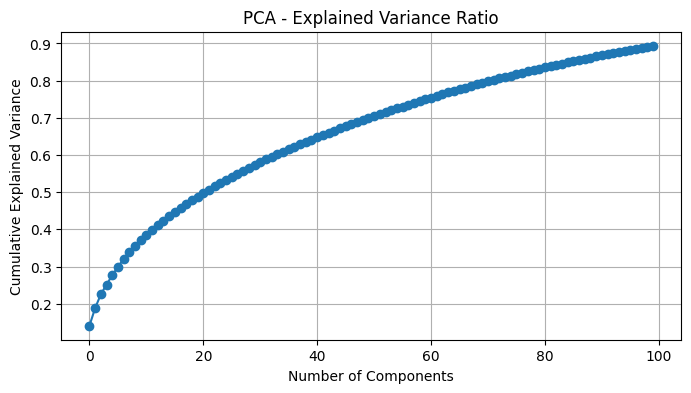

✅ 100 components explain 89.38% of the variance.


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# applying PCA (Principal Component Analysis) to reduce feature dimensions
# I'm keeping only the top 100 components out of the original 32k+ features extracted from VGG16
# this helps compress the data while retaining most of the important information (variance)
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_scaled)   # fitting PCA on training data
X_test_pca = pca.transform(X_test_scaled)         # applying the same transformation on test data

# plotting the cumulative explained variance to visualize how much information is retained
# the curve helps decide the optimal number of components that capture most of the variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance Ratio")
plt.grid(True)
plt.show()

# showing how much total variance is captured by the 100 PCA components
# this value tells us how well the reduced data still represents the original information
print(f"✅ 100 components explain {np.sum(pca.explained_variance_ratio_):.2%} of the variance.")


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# applying VarianceThreshold to remove features that don't vary much across samples
# features with very low variance usually don't add any useful information for classification
# so setting threshold=0.01 means we'll drop all features whose variance is below 0.01
selector = VarianceThreshold(threshold=0.01)

# fitting the selector on training data and transforming both train and test sets
# this keeps only the features that pass the variance threshold
X_train_fs = selector.fit_transform(X_train_scaled)
X_test_fs = selector.transform(X_test_scaled)

# checking the number of features before and after applying feature selection
# this helps confirm how many uninformative features got removed
print("Before feature selection:", X_train_scaled.shape)
print("After feature selection:", X_train_fs.shape)


Before feature selection: (163, 32768)
After feature selection: (163, 18748)


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# here I'm training the same Logistic Regression model, but this time on PCA-transformed features
# the idea is to check whether reducing dimensionality (via PCA) affects accuracy or not
lr_pca = LogisticRegression(max_iter=2000)   # increased max_iter to ensure the model fully converges
lr_pca.fit(X_train_pca, y_train)             # fitting the model on training data after PCA transformation
y_pred_pca = lr_pca.predict(X_test_pca)      # predicting labels for test data

# checking the accuracy of the model after applying PCA
print("Accuracy after PCA:", accuracy_score(y_test, y_pred_pca))

# generating a detailed classification report (precision, recall, f1-score) to compare performance
# this helps in verifying if the reduced features still hold enough information for classification
print("\nClassification Report (after PCA):\n", classification_report(y_test, y_pred_pca, target_names=le.classes_))


Accuracy after PCA: 0.9024390243902439

Classification Report (after PCA):
               precision    recall  f1-score   support

     healthy       0.87      0.95      0.91        21
   parkinson       0.94      0.85      0.89        20

    accuracy                           0.90        41
   macro avg       0.91      0.90      0.90        41
weighted avg       0.91      0.90      0.90        41

